In [36]:
# reading in the libraries and functions that we will need as we do this work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
Ames = pd.read_csv("https://webpages.charlotte.edu/mschuck1/classes/DTSC2302/student-performance_n_600.csv", na_values=['NA'])
# remove rows with missing data
Ames.dropna(inplace=True)
Ames.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0.648298,MS,F,17,U,GT3,T,1,1,other,...,4,3,2,1,2,5,9,7,9,10
1,0.522011,MS,F,16,R,GT3,T,2,3,at_home,...,4,5,2,1,2,5,0,16,17,17
2,0.119924,MS,M,16,U,LE3,T,2,2,services,...,5,1,3,2,2,3,0,10,9,10
3,0.519012,GP,F,16,U,GT3,T,2,2,other,...,5,4,4,1,1,5,0,12,11,11
4,0.996449,GP,F,16,U,LE3,T,2,4,other,...,4,2,2,1,2,5,2,14,12,13


In [38]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
# Create a LabelEncoder object
label_encoder = LabelEncoder()
# List of categorical columns to encode (you can modify this list based on your dataset)
categorical_columns = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
# Apply LabelEncoder to each categorical column in the dataset
for column in categorical_columns:
    Ames[column] = label_encoder.fit_transform(Ames[column])
X = Ames[['school','sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']]  # Features (2D array)
y = Ames['G3']

Root Mean Squared Error: 1.2188814317916559
Coefficients: [-0.25318541 -0.08914035  0.05306083  0.10168008  0.02911665 -0.15248818
 -0.04047575  0.03255756  0.01256034 -0.11462626 -0.0888012  -0.01778282
  0.13537187  0.04588721 -0.21523891 -0.22954185  0.14590674 -0.06194621
  0.04609389 -0.07496312  0.30666642  0.05845565 -0.079181   -0.01139403
 -0.04067104 -0.02734894 -0.02543667 -0.01882778 -0.0537264   0.01227855
  0.13780397  0.86410428]
Intercept: -0.07350388229032667


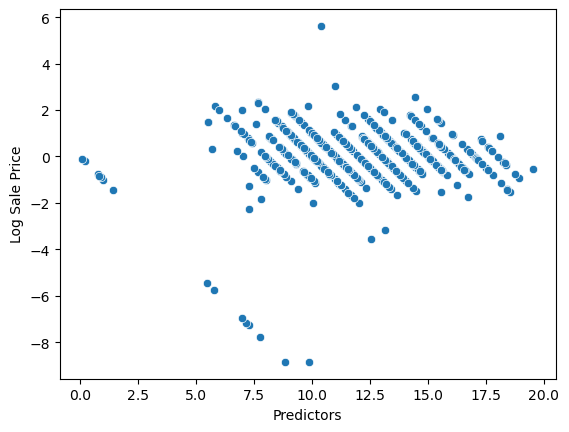

In [39]:
# Create a linear regression model
p_model = LinearRegression()

# Fit the model on the  data
p_model.fit(X, y)

# Make predictions on the  data
y_hat = p_model.predict(X)


# a look at the residual vs fitted plot
sns.scatterplot(x=y_hat, y=y-y_hat)
plt.ylabel('Log Sale Price')
plt.xlabel('Predictors')
# Evaluate the model performance
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

# Get the coefficients and intercept
print('Coefficients:', p_model.coef_)
print('Intercept:', p_model.intercept_)

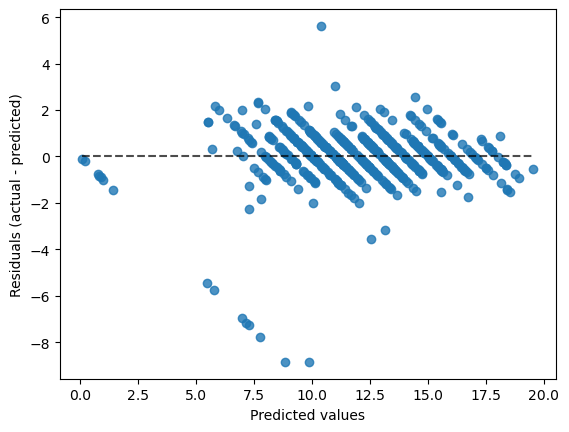

In [40]:
# below makes a residual vs predicted values plot
display = PredictionErrorDisplay(y_true=y, y_pred=y_hat)
display.plot()
plt.show()

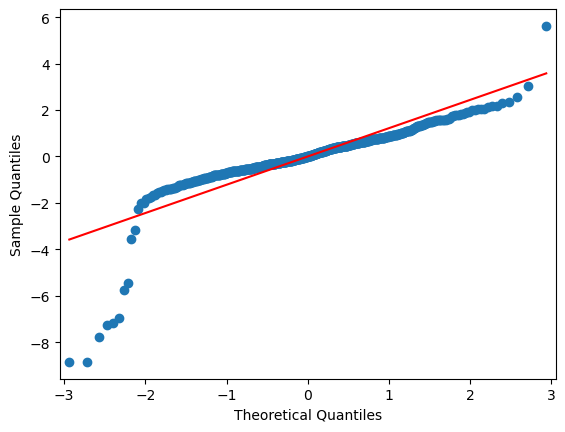

In [41]:
# calculate the residuals 
Ames_residuals = y - y_hat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(Ames_residuals, line ='s') 
# 
py.show() 

In [42]:
x2 = sm.add_constant(X)

#fit linear regression model
model2 = sm.OLS(y, x2).fit()

#view model summary
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     107.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          3.99e-217
Time:                        16:00:32   Log-Likelihood:                -970.12
No. Observations:                 600   AIC:                             2006.
Df Residuals:                     567   BIC:                             2151.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0735      0.972     -0.076      0.9